# Experimentos — MLP do Zero no MNIST

Este notebook é o **driver de experimentos**. Toda a rede (forward, backprop,
ativações, loss e optimizer) está implementada do zero, só com NumPy, no pacote
[`mlp/`](../mlp). Aqui eu apenas carrego os dados, treino, ploto as curvas e
comparo configurações.

**Roteiro:**
1. Carregar e preparar o MNIST
2. Treinar o modelo principal (`[784, 128, 64, 10]`, ReLU, SGD)
3. Curvas de loss e acurácia
4. Avaliação no conjunto de teste (meta: **≥ 92%**)
5. Matriz de confusão
6. Comparação de configurações (ReLU × sigmoid, learning rate)

## 0. Setup

Importo o pacote `mlp/` (a raiz do projeto é adicionada ao `sys.path`) e fixo a
seed para reprodutibilidade.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets

# garante que a raiz do projeto (que contém a pasta mlp/) esteja no path
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from mlp.network import MLP
from mlp.optimizers import SGD

DATA_DIR = os.path.join(PROJECT_ROOT, "data")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

np.random.seed(42)
print("Setup ok. Resultados serão salvos em:", RESULTS_DIR)

Setup ok. Resultados serão salvos em: /Users/guilhermeholanda/Desktop/mlp-from-scratch/results


## 1. Carregando e preparando o MNIST

Uso o `torchvision` apenas para **baixar** o dataset (a atividade permite isso) —
a rede em si não usa nenhum framework. Três passos de pré-processamento:

- **achatar**: cada imagem 28×28 vira um vetor de 784 valores (a entrada do MLP);
- **normalizar**: divido por 255 para os pixels ficarem em [0, 1] (ajuda o treino);
- **one-hot**: o rótulo `3` vira `[0,0,0,1,0,0,0,0,0,0]`, casando com a softmax.

In [2]:
train = datasets.MNIST(root=DATA_DIR, train=True, download=True)
test = datasets.MNIST(root=DATA_DIR, train=False, download=True)

# imagens 28x28 -> vetor de 784; normaliza para [0, 1]
X_train = train.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
X_test = test.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_train = train.targets.numpy()
y_test = test.targets.numpy()

def one_hot(y, n_classes=10):
    out = np.zeros((y.size, n_classes))
    out[np.arange(y.size), y] = 1
    return out

Y_train = one_hot(y_train)
Y_test = one_hot(y_test)

print("treino:", X_train.shape, Y_train.shape)
print("teste: ", X_test.shape, Y_test.shape)
print("pixels no intervalo [%.1f, %.1f]" % (X_train.min(), X_train.max()))

100%|██████████| 9.91M/9.91M [00:08<00:00, 1.16MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 252kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.05MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.53MB/s]

treino: (60000, 784) (60000, 10)
teste:  (10000, 784) (10000, 10)
pixels no intervalo [0.0, 1.0]


Vamos visualizar algumas amostras para confirmar que os dados e rótulos
estão coerentes:

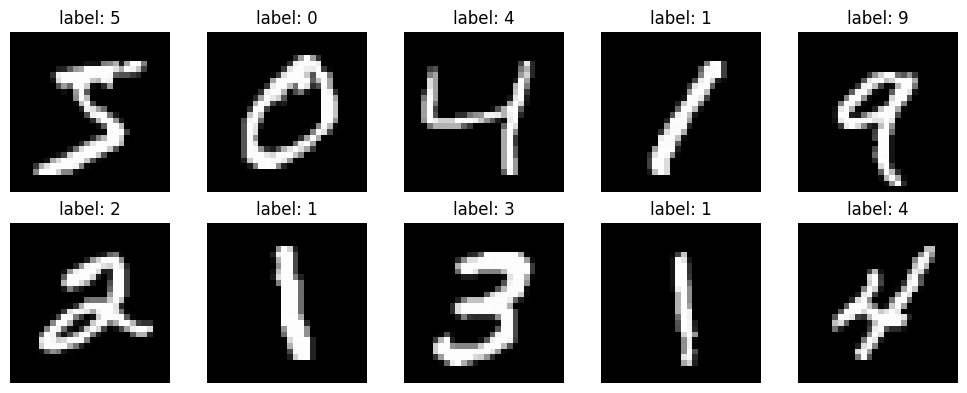

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.ravel(), range(10)):
    ax.imshow(X_train[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"label: {y_train[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "amostras_mnist.png"), dpi=120)
plt.show()

## 2. Treinando o modelo principal

**Arquitetura escolhida:** `[784, 128, 64, 10]` — entrada de 784, **duas camadas
ocultas** (128 e 64 neurônios) com **ReLU**, e saída de 10 com **softmax**.

- *Por que 2 camadas ocultas?* É o mínimo pedido e já é suficiente para o MNIST;
  a primeira aprende traços simples, a segunda combina em padrões mais complexos.
- *Por que ReLU?* Não satura, então o gradiente não "some" ao atravessar as
  camadas (ao contrário da sigmoid).
- *Treino:* SGD por mini-batches de 64, learning rate 0.1, 15 épocas.

In [4]:
modelo = MLP([784, 128, 64, 10], optimizer=SGD(learning_rate=0.1), activation="relu")
historico = modelo.fit(X_train, Y_train, n_epochs=15, batch_size=64, verbose=True)

Época   1/15 - loss: 0.1741 - acc: 0.9498
Época   2/15 - loss: 0.1258 - acc: 0.9631
Época   3/15 - loss: 0.0978 - acc: 0.9698
Época   4/15 - loss: 0.0858 - acc: 0.9739
Época   5/15 - loss: 0.0581 - acc: 0.9832
Época   6/15 - loss: 0.0466 - acc: 0.9869
Época   7/15 - loss: 0.0387 - acc: 0.9886
Época   8/15 - loss: 0.0312 - acc: 0.9917
Época   9/15 - loss: 0.0496 - acc: 0.9840
Época  10/15 - loss: 0.0242 - acc: 0.9933
Época  11/15 - loss: 0.0210 - acc: 0.9942
Época  12/15 - loss: 0.0224 - acc: 0.9938
Época  13/15 - loss: 0.0130 - acc: 0.9974
Época  14/15 - loss: 0.0128 - acc: 0.9972
Época  15/15 - loss: 0.0105 - acc: 0.9980


## 3. Curvas de loss e acurácia

A loss deve cair de forma consistente e a acurácia (no treino) subir. Se a loss
não caísse, seria sinal de gradiente errado.

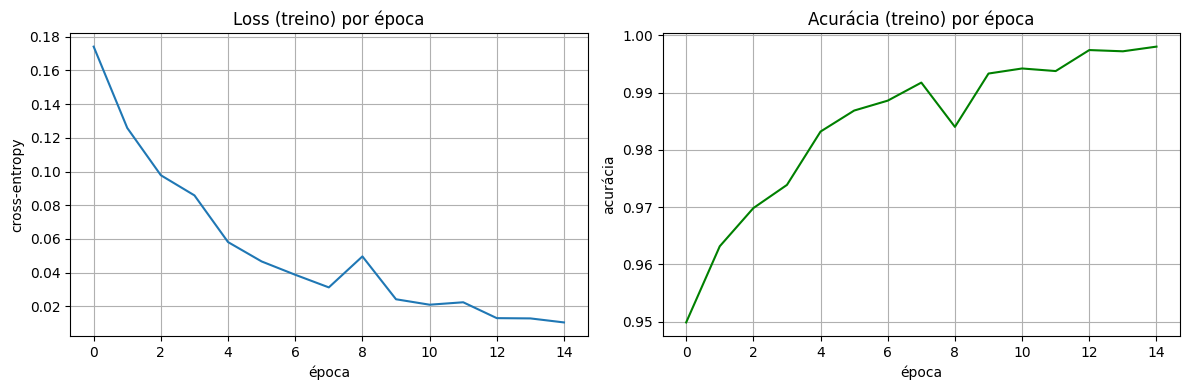

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historico["loss"])
ax1.set_title("Loss (treino) por época")
ax1.set_xlabel("época"); ax1.set_ylabel("cross-entropy"); ax1.grid(True)

ax2.plot(historico["acc"], color="green")
ax2.set_title("Acurácia (treino) por época")
ax2.set_xlabel("época"); ax2.set_ylabel("acurácia"); ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "curvas_treino.png"), dpi=120)
plt.show()

## 4. Avaliação no conjunto de teste

O número que importa: acurácia em dados que a rede **nunca viu**.

In [6]:
acc_teste = modelo.accuracy(X_test, Y_test)
print(f"Acurácia no conjunto de TESTE: {acc_teste:.4f}  ({acc_teste*100:.2f}%)")
print("Meta de >= 92%:", "ATINGIDA" if acc_teste >= 0.92 else "NAO atingida")

Acurácia no conjunto de TESTE: 0.9765  (97.65%)
Meta de >= 92%: ATINGIDA


## 5. Matriz de confusão

Mostra onde a rede erra: a linha é o dígito verdadeiro, a coluna é o previsto.
A diagonal são os acertos; valores fora dela são as confusões (ex.: 4 previsto
como 9).

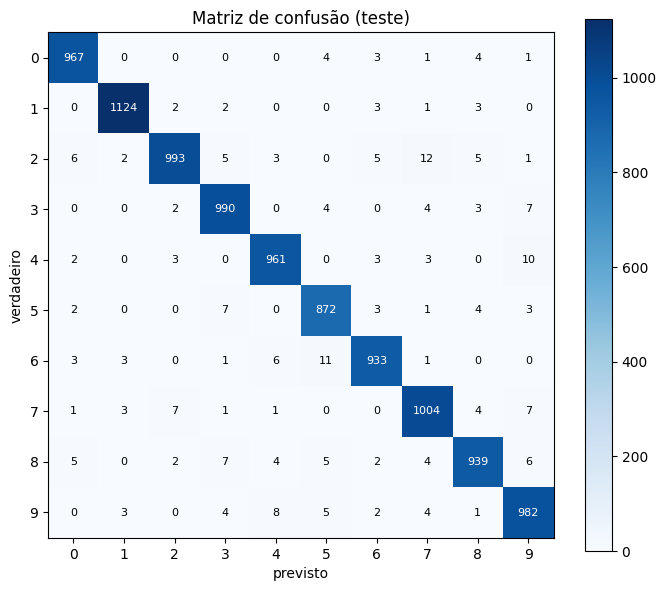

In [7]:
def matriz_confusao(y_true, y_pred, n=10):
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

y_pred_teste = modelo.predict(X_test)
cm = matriz_confusao(y_test, y_pred_teste)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Matriz de confusão (teste)")
ax.set_xlabel("previsto"); ax.set_ylabel("verdadeiro")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
plt.colorbar(im)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "matriz_confusao.png"), dpi=120)
plt.show()

## 6. Comparação de configurações

Requisito da atividade: comparar ao menos 2 configurações. Eu comparo três,
mudando **uma coisa por vez** para isolar o efeito:

1. **ReLU, lr=0.1** — baseline (igual ao modelo principal)
2. **Sigmoid, lr=0.1** — troca só a ativação das ocultas
3. **ReLU, lr=0.01** — troca só o learning rate

Para uma comparação justa, reinicializo a seed antes de cada uma (mesma
inicialização de pesos) e uso 10 épocas em todas.

In [8]:
configs = [
    {"nome": "ReLU, lr=0.1 (baseline)", "layers": [784, 128, 64, 10], "act": "relu",    "lr": 0.1},
    {"nome": "Sigmoid, lr=0.1",         "layers": [784, 128, 64, 10], "act": "sigmoid", "lr": 0.1},
    {"nome": "ReLU, lr=0.01",           "layers": [784, 128, 64, 10], "act": "relu",    "lr": 0.01},
]

resultados = []
historicos = {}
for cfg in configs:
    np.random.seed(42)  # mesma inicialização -> comparação justa
    net = MLP(cfg["layers"], optimizer=SGD(learning_rate=cfg["lr"]), activation=cfg["act"])
    h = net.fit(X_train, Y_train, n_epochs=10, batch_size=64, verbose=False)
    acc = net.accuracy(X_test, Y_test)
    historicos[cfg["nome"]] = h
    resultados.append((cfg["nome"], acc))
    print(f"{cfg['nome']:28s} -> acc teste: {acc:.4f}")

ReLU, lr=0.1 (baseline)      -> acc teste: 0.9779
Sigmoid, lr=0.1              -> acc teste: 0.9451
ReLU, lr=0.01                -> acc teste: 0.9529


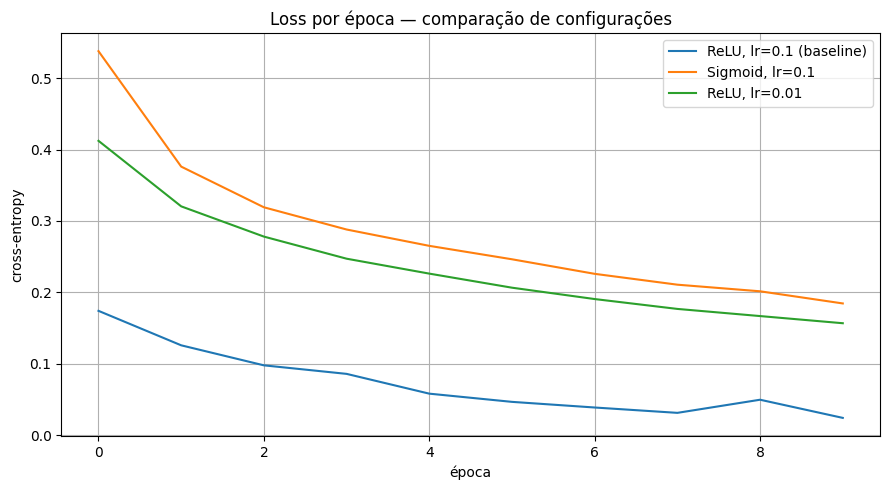


Resumo (acurácia no teste):
configuração                  acc teste
----------------------------------------
ReLU, lr=0.1 (baseline)         0.9779
Sigmoid, lr=0.1                 0.9451
ReLU, lr=0.01                   0.9529


In [9]:
# Curvas de loss das três configurações sobrepostas
plt.figure(figsize=(9, 5))
for nome, h in historicos.items():
    plt.plot(h["loss"], label=nome)
plt.title("Loss por época — comparação de configurações")
plt.xlabel("época"); plt.ylabel("cross-entropy")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "comparacao_loss.png"), dpi=120)
plt.show()

# Tabela-resumo
print("\nResumo (acurácia no teste):")
print(f"{'configuração':28s} {'acc teste':>10s}")
print("-" * 40)
for nome, acc in resultados:
    print(f"{nome:28s} {acc:>9.4f}")

## 7. Conclusões

- O modelo principal (ReLU, 2 camadas ocultas) **supera a meta de 92%** no teste.
- Na comparação, observe (veja a tabela e o gráfico acima):
  - **ReLU × sigmoid:** com a mesma arquitetura e learning rate, a ReLU costuma
    convergir mais rápido e chegar a uma acurácia melhor — efeito do *vanishing
    gradient* da sigmoid em redes com mais de uma camada oculta.
  - **learning rate:** um lr muito baixo (0.01) faz a loss cair devagar; em 10
    épocas ele ainda não alcança o baseline.

> A reflexão pessoal (decisão mais difícil, o que não funcionou, o que faria
> diferente) vai na seção **"Decisões e dificuldades"** do `README.md` — essa
> parte é sua e o enunciado pede que seja escrita em primeira pessoa.